# Time-Sliced Detection: Hourly Spatial Consistency Anomalies

**Notebook 06 of the spatiotemporal air quality anomaly detection pipeline**

---

This notebook re-applies the spatial consistency test of Notebook 03 at hourly resolution:
rather than comparing each station's whole-period median against its neighbours once, it
compares every hourly reading against the neighbourhood at that same hour, across the full
observation window. A station whose spatial baseline is unremarkable overall can still
report inconsistently at specific hours — an intermittent fault, a transient manipulation
episode, a sensor drift that self-corrects — and this notebook is designed to surface exactly
that behaviour.

| | |
|---|---|
| **Input** | `countries/anomaly_*.csv`, `config/params.yml` |
| **Output** | `station_suspicion_tsad.csv` |
| **Downstream** | the consensus notebook (`consensus.ipynb`) — cross-method consensus |


## Contents

0. **Method Context**
   - 0.1 Objective
   - 0.2 Approach and Principles
   - 0.3 Inputs and Outputs
1. **Environment and Data**
   - 1.1 Configuration
   - 1.2 Input Loading and Validation
2. **Hourly Slicing and the Value Matrix**
   - 2.1 Hourly Time Slices
   - 2.2 Station-by-Slice Value Matrix
3. **Spatial Neighbour Definition**
   - 3.1 Adjacency Matrix
   - 3.2 Neighbour Coverage
4. **Per-Slice Modified Z-Score**
   - 4.1 Leave-One-Out Neighbour Statistics per Slice
   - 4.2 Modified Z-Score Computation
5. **Cross-Slice Aggregation**
   - 5.1 Minimum Assessable Slices
   - 5.2 Anomaly Rate per Station
6. **Suspicion Threshold and Flagging**
   - 6.1 Flagging Rate Sensitivity
   - 6.2 Flagging and Direction
7. **Results and Handoff**
   - 7.1 Flagged Stations
   - 7.2 Consensus-Ready Output
   - 7.3 Output Validation
8. **Findings and Limitations**

---

Terminology

- An **hourly slice** is the set of every station's reading at one specific calendar hour
  across the observation window.
- A slice is **assessable** for a station if that station reported at that hour and had
  enough active neighbours reporting at the same hour.
- The **anomaly rate** is the share of a station's assessable slices in which its modified
  Z-score exceeded the suspicion threshold — how often, not merely whether, a station
  deviates from its neighbourhood.
- **SL** (systematically low) and **SH** (systematically high) denote the direction of a
  station's average deviation, following Chen et al. (2018).


## 0. Method Context

### 0.1 Objective

The spatial baseline in Notebook 03 reduces each station to a single value — its
whole-period median — before comparing it against its neighbours. That reduction is
efficient and interpretable, but it discards timing entirely: a station that under-reports
consistently for one month and reports normally for the rest of the year contributes an
aggregate median close to normal, and the whole-period comparison has no way to see the
month it misbehaved.

This notebook restores the timing dimension. The same leave-one-out spatial comparison
applied once in Notebook 03 is instead applied independently at every hourly slice in the
observation window — tens of thousands of times per network — and a station's suspicion is
then a property of how often it deviates, not merely whether its long-run average does.

Two objectives follow:

1. **Detect stations whose deviation is transient rather than persistent.** <br>A station
   flagged here but not in Notebook 03 has behaved anomalously at specific hours without
   shifting its whole-period average enough to register as a baseline outlier — precisely
   the failure mode the static comparison cannot reach.</br>

2. **Distinguish occasional deviation from systematic deviation.** <br>Every station
   deviates from its neighbours at some hours by chance; the anomaly rate — the share of
   assessable slices in which a station deviates — separates a station that does this
   rarely from one that does it persistently.</br>


### 0.2 Approach and Principles

Four decisions govern the implementation, extending those established in Notebook 03 to the
time-sliced setting.

1. **Per-country, per-slice leave-one-out comparison.** <br>At every hourly slice, a
   station's reading is compared against the same-country neighbours reporting at that same
   hour, excluding the station itself from its own reference — identical in spirit to
   Notebook 03, applied independently at every slice rather than once over the whole
   period.</br>

2. **The modified Z-score, not the classical one.** <br>Notebook 03 adopted the median and
   median absolute deviation over the mean and standard deviation, because the concentration
   distributions are log-normal and a classical Z-score is displaced by the upper tail. The
   same reasoning applies identically at every hourly slice, so this notebook uses the same
   modified Z-score and the same anchor (Iglewicz & Hoaglin, 1993; threshold 3.5) that
   Notebook 03 established, rather than a separate, inconsistent convention.</br>

3. **A slice must meet the same neighbour-sufficiency bar as the static baseline.** <br>A
   slice is assessable for a station only if that station and at least the configured
   minimum number of neighbours are simultaneously active at that hour. Most hourly slices
   fail this bar for most stations — reporting networks are rarely all active at once — so
   the aggregation in Section 5 operates on a station-specific subset of slices, not the
   full time index.</br>

4. **Suspicion is frequency, and both frequency and its threshold are examined rather than
   assumed.** <br>A station's suspicion score is the share of its assessable slices flagged
   as deviant, and the rate at which that share itself becomes suspicious is derived by
   sensitivity analysis in Section 6, rather than fixed at an arbitrary convention.</br>


### 0.3 Inputs and Outputs

| Direction | Artifact | Contents |
|---|---|---|
| **In** | `countries/anomaly_*.csv` | Per-country analytical datasets (Notebook 02) |
| **In** | `config/params.yml` | Radius, minimum neighbours, modified Z-score threshold |
| **Out** | `station_suspicion_tsad.csv` | Per-station anomaly rate, suspicion score, flag, and direction |

The output schema matches the other detection notebooks — `location_id`, `country`,
`suspicion_score`, `flagged`, `direction` — so that the consensus notebook (`consensus.ipynb`) can combine methods without
per-method special handling.

This notebook reads no output from any other detection notebook, including Notebook 03: the
two methods share a spatial mechanism and a threshold convention by design, but each reaches
its own verdict from the raw observational record independently.


## 1. Environment and Data

### 1.1 Configuration

All parameters governing this notebook — the per-country radius, the minimum neighbour
count, and the modified Z-score threshold — are the same values Notebook 03 already derived
and validated. None is re-derived here; reusing them is what keeps the two methods
comparable.


In [1]:
import glob
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_style import table_style

# ── Configuration ────────────────────────────────────────────────────
CONFIG_PATH = Path("../config/params.yml")
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"{CONFIG_PATH} not found.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

REQUIRED_SECTIONS = ["meta", "spatial", "tsad", "paths", "colors_map"]
_missing = [s for s in REQUIRED_SECTIONS if s not in CONFIG]
if _missing:
    raise KeyError(f"Missing configuration section(s): {_missing}")

PROCESSED_DIR = Path(CONFIG["paths"]["processed_dir"])
FIGURE_DIR    = PROCESSED_DIR.parent.parent / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

COUNTRY_COLOURS = CONFIG["colors_map"]
COUNTRY_ORDER   = ["China", "Germany", "India", "USA"]
RANDOM_SEED     = CONFIG["meta"]["random_seed"]

MIN_NEIGHBORS     = CONFIG["spatial"]["min_neighbors"]
DEFAULT_RADIUS    = CONFIG["spatial"]["radius_km"]["default"]
ZSCORE_THRESHOLD  = CONFIG["tsad"]["zscore_suspicion_threshold"]
ROBUST_SCALE      = 1.4826   # MAD-to-σ consistency constant (Iglewicz & Hoaglin, 1993)

def radius_for(country: str) -> float:
    r = CONFIG["spatial"]["radius_km"].get(country)
    return r if r is not None else DEFAULT_RADIUS

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)

parameters = pd.DataFrame([
    ("Minimum neighbours", MIN_NEIGHBORS, "Shared with Notebook 03 (NB02 §7.3)"),
    ("Modified Z-score threshold", ZSCORE_THRESHOLD, "Shared with Notebook 03 (Iglewicz & Hoaglin, 1993)"),
    *[(f"Radius — {c} (km)", radius_for(c), "Shared with Notebook 03 (NB02 §6.4)") for c in COUNTRY_ORDER],
], columns=["Parameter", "Value", "Source"]).set_index("Parameter")

display(table_style(parameters))


,Parameter,Value,Source
0,Minimum neighbours,3.000000,Shared with Notebook 03 (NB02 §7.3)
1,Modified Z-score threshold,3.500000,"Shared with Notebook 03 (Iglewicz & Hoaglin, 1993)"
2,Radius — China (km),50.000000,Shared with Notebook 03 (NB02 §6.4)
3,Radius — Germany (km),50.000000,Shared with Notebook 03 (NB02 §6.4)
4,Radius — India (km),100.000000,Shared with Notebook 03 (NB02 §6.4)
5,Radius — USA (km),150.000000,Shared with Notebook 03 (NB02 §6.4)


<u>Interpretation</u>

Every spatial and statistical parameter this notebook uses is the same value Notebook 03
already validated, reused rather than re-derived. This is deliberate: the two notebooks
apply the same method at different time resolutions, and identical parameters are what make
a comparison between their results meaningful.


### 1.2 Input Loading and Validation

The per-country files written by Notebook 02 are the sole input. Timestamps are floored to
the calendar hour immediately on load, since the hourly slice is this notebook's unit of
analysis throughout.


In [2]:
country_files = sorted(glob.glob(str(PROCESSED_DIR / "countries" / "anomaly_*.csv")))
if not country_files:
    raise FileNotFoundError(
        "Per-country files not found in data/processed/countries/. "
        "Run 02_exploratory_data_analysis.ipynb (Section 8) to completion first."
    )

meas = pd.concat([pd.read_csv(f) for f in country_files], ignore_index=True)
meas["date"] = pd.to_datetime(meas["date"], utc=True, errors="coerce")

REQUIRED_COLUMNS = {"location_id", "country", "value", "date", "latitude", "longitude"}
_absent = REQUIRED_COLUMNS - set(meas.columns)
if _absent:
    raise KeyError(f"Fields required for time-sliced detection are absent: {_absent}")

meas["hour_slice"] = meas["date"].dt.floor("h")
meas = meas.dropna(subset=["hour_slice", "value"])

loaded = pd.DataFrame([
    ("Observations",   f"{len(meas):,}"),
    ("Stations",       f"{meas['location_id'].nunique():,}"),
    ("Hourly slices",  f"{meas['hour_slice'].nunique():,}"),
    ("Slice range",    f"{meas['hour_slice'].min()} to {meas['hour_slice'].max()}"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(loaded))


/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_25224/3080152134.py:8: DtypeWarning: Columns (0: review_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  meas = pd.concat([pd.read_csv(f) for f in country_files], ignore_index=True)


,Property,Value
0,Observations,"40,505,358"
1,Stations,"3,150"
2,Hourly slices,"26,280"
3,Slice range,2021-01-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00


<u>Interpretation</u>

The eligible per-country record loads with an hourly slice assigned to every observation.
The slice count — tens of thousands across the observation window — is the scale at which
the per-slice comparison in Section 4 operates, and is also why the aggregation in Section 5
must apply a minimum-assessable-slices bar: most individual slices will not have enough
simultaneously active stations to support every station's comparison.


## 2. Hourly Slicing and the Value Matrix

The per-slice comparison in Section 4 operates on a dense station-by-slice matrix rather
than the long-format observation table, since the same neighbour comparison must be
repeated independently at every one of tens of thousands of slices. This section builds that
matrix once.


### 2.1 Hourly Time Slices

Each observation already carries the hour-floored timestamp assigned in Section 1.2. The
slice index for the value matrix is simply the sorted set of distinct hours present in the
eligible record.


In [3]:
stations = (meas.groupby("location_id")
            .agg(country=("country", "first"),
                 latitude=("latitude", "first"),
                 longitude=("longitude", "first"))
            .reset_index())
N = len(stations)

hour_index = np.sort(meas["hour_slice"].unique())
T = len(hour_index)

display(table_style(pd.DataFrame([
    ("Stations (matrix columns)", f"{N:,}"),
    ("Hourly slices (matrix rows)", f"{T:,}"),
    ("Matrix cells", f"{N * T:,}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Stations (matrix columns),"3,150"
1,Hourly slices (matrix rows),"26,280"
2,Matrix cells,"82,782,000"


<u>Interpretation</u>

The dimensions of the value matrix set the scale of every computation that follows. Most
cells in a matrix this size will be empty for any single station — no network reports at
every one of tens of thousands of hours — which is precisely why Section 5 conditions the
aggregation on a minimum count of assessable slices rather than assuming every slice
contributes.


### 2.2 Station-by-Slice Value Matrix

Observations are pivoted into a dense matrix with one row per hourly slice and one column
per station, ordered to match the station list fixed in Section 2.1. A station-hour with no
report is represented as a missing cell rather than a zero, so that absence of a reading is
never mistaken for a reading of zero.


In [4]:
pivot = (meas.pivot_table(index="hour_slice", columns="location_id",
                          values="value", aggfunc="mean")
          .reindex(index=hour_index, columns=stations["location_id"]))
V = pivot.values   # (T slices × N stations); NaN where a station did not report

fill_rate = np.isfinite(V).mean() * 100
display(table_style(pd.DataFrame([
    ("Matrix shape", f"{V.shape[0]:,} × {V.shape[1]:,}"),
    ("Filled cells (station reporting)", f"{np.isfinite(V).sum():,} ({fill_rate:.1f}%)"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Matrix shape,"26,280 × 3,150"
1,Filled cells (station reporting),"40,505,358 (48.9%)"


<u>Interpretation</u>

The fill rate is a first indication of how sparse the per-slice comparison will be: a low
figure means most station-hour combinations are empty, and the neighbour-sufficiency bar in
Section 3 and Section 5 will exclude the large majority of slices from most stations'
assessment. This sparsity is expected and not itself a data-quality concern — no real-world
monitoring network reports at every station every hour without exception.


## 3. Spatial Neighbour Definition

The neighbourhood structure is identical to Notebook 03: same-country stations within the
country's derived radius. It is rebuilt here from the same coordinates and the same
configuration, rather than imported from Notebook 03's own output, since notebooks in this
pipeline do not read one another's results.


### 3.1 Adjacency Matrix

An N-by-N boolean adjacency matrix marks which station pairs are neighbours: same country,
within radius, excluding a station from its own neighbour set.


In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometres between coordinate arrays."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


lat, lon, ctry = stations["latitude"].values, stations["longitude"].values, stations["country"].values
adjacency = np.zeros((N, N), dtype=bool)

for i in range(N):
    d = haversine_km(lat[i], lon[i], lat, lon)
    same_country = ctry == ctry[i]
    adjacency[i] = (d <= radius_for(ctry[i])) & (d > 0) & same_country

display(table_style(pd.DataFrame([
    ("Adjacency matrix shape", f"{N} × {N}"),
    ("Stations with ≥ minimum neighbours", f"{(adjacency.sum(axis=1) >= MIN_NEIGHBORS).sum()} / {N}"),
    ("Mean neighbours per station", f"{adjacency.sum(axis=1).mean():.1f}"),
], columns=["Property", "Value"]).set_index("Property")))


,Property,Value
0,Adjacency matrix shape,3150 × 3150
1,Stations with ≥ minimum neighbours,2754 / 3150
2,Mean neighbours per station,10.8


<u>Interpretation</u>

The adjacency structure reproduces the same neighbour relationships Notebook 03 established,
using the same radii. This is the geometric precondition for the per-slice comparison; how
often those geometric neighbours are actually active at the same hour — the precondition
that matters for this notebook specifically — is examined next.


### 3.2 Neighbour Coverage

Geometric adjacency is necessary but not sufficient: a station's neighbours must also be
simultaneously reporting at a given hour for that hour to be assessable. This section reports
the static, geometry-only coverage; Section 5.1 measures how much of it survives contact
with actual reporting patterns.


In [6]:
coverage_by_country = (stations.assign(n_neighbours=adjacency.sum(axis=1))
                       .groupby("country")["n_neighbours"]
                       .agg(median="median", below_minimum=lambda s: (s < MIN_NEIGHBORS).sum())
                       .reindex([c for c in COUNTRY_ORDER if c in stations["country"].values]))

display(table_style(coverage_by_country))


,country,median,below_minimum
0,China,6.000000,186
1,Germany,6.000000,48
2,India,9.000000,73
3,USA,9.000000,89


<u>Interpretation</u>

The per-country neighbour counts mirror the density pattern established throughout this
pipeline: networks with a small derived radius are dense enough that few stations fall below
the minimum, while sparser networks carry a larger share of geometrically under-connected
stations from the outset. Section 5 makes the further, stricter cut for slices where
geometric neighbours are also temporally absent.


## 4. Per-Slice Modified Z-Score

With the value matrix and the adjacency structure in place, a modified Z-score is computed
independently at every hourly slice, for every station with a sufficient active
neighbourhood at that slice.


### 4.1 Leave-One-Out Neighbour Statistics per Slice

For each station, its neighbours' values across every slice are gathered into a
slice-by-neighbour matrix, and the median and median absolute deviation are computed
row-wise — one robust reference per slice, using only that slice's actively reporting
neighbours, automatically excluding the station itself since it is not a member of its own
neighbour set.

The median and MAD have no equivalent to the matrix-multiplication shortcut a mean and
variance admit, so this computation is vectorised across slices for each station in turn,
rather than across the full station-by-slice matrix in a single operation. With station
counts in the hundreds and slice counts in the tens of thousands, this remains efficient: the
per-slice cost is paid once per station, not once per station-slice pair.


In [7]:
def per_station_modified_z(own_col: np.ndarray, neighbour_cols: np.ndarray) -> np.ndarray:
    """Leave-one-out modified Z-score of one station against its neighbours, per slice.

    own_col: (T,) the station's own value at every slice.
    neighbour_cols: (T, n_neighbours) the neighbours' values at every slice.
    Returns an array of shape (T,) with NaN where the slice cannot be assessed.
    """
    active_count = np.isfinite(neighbour_cols).sum(axis=1)
    neighbour_median = np.nanmedian(neighbour_cols, axis=1)
    abs_deviation = np.abs(neighbour_cols - neighbour_median[:, None])
    neighbour_mad = np.nanmedian(abs_deviation, axis=1)

    with np.errstate(invalid="ignore", divide="ignore"):
        z = (own_col - neighbour_median) / (ROBUST_SCALE * neighbour_mad)

    valid = (
        np.isfinite(own_col)
        & (active_count >= MIN_NEIGHBORS)
        & (neighbour_mad > 0)
    )
    return np.where(valid, z, np.nan)


Zmat = np.full((T, N), np.nan)
for i in range(N):
    neighbour_idx = np.where(adjacency[i])[0]
    if len(neighbour_idx) < MIN_NEIGHBORS:
        continue
    Zmat[:, i] = per_station_modified_z(V[:, i], V[:, neighbour_idx])

n_valid = np.isfinite(Zmat).sum()
display(table_style(pd.DataFrame([
    ("Modified Z-scores computed", f"{n_valid:,}"),
    ("Share of matrix cells", f"{n_valid / (T * N) * 100:.2f}%"),
], columns=["Property", "Value"]).set_index("Property")))


/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_25224/1781290383.py:9: RuntimeWarning: All-NaN slice encountered
  neighbour_median = np.nanmedian(neighbour_cols, axis=1)
/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_25224/1781290383.py:11: RuntimeWarning: All-NaN slice encountered
  neighbour_mad = np.nanmedian(abs_deviation, axis=1)


,Property,Value
0,Modified Z-scores computed,"33,248,958"
1,Share of matrix cells,40.16%


<u>Interpretation</u>

The share of matrix cells carrying a valid score is small in absolute terms, and this is
expected rather than a defect: a slice contributes a valid score for a station only when
that station and enough of its neighbours are simultaneously active, a stricter condition
than either being active alone. Section 5 aggregates across exactly the slices that do
qualify, per station, rather than treating the full slice count as the denominator.


### 4.2 Modified Z-Score Computation

Having computed the matrix, the distribution of valid scores is examined before any
threshold is applied — the same diagnostic step Notebook 03 performs before deriving its
own threshold, here applied to confirm the per-slice scores behave comparably.


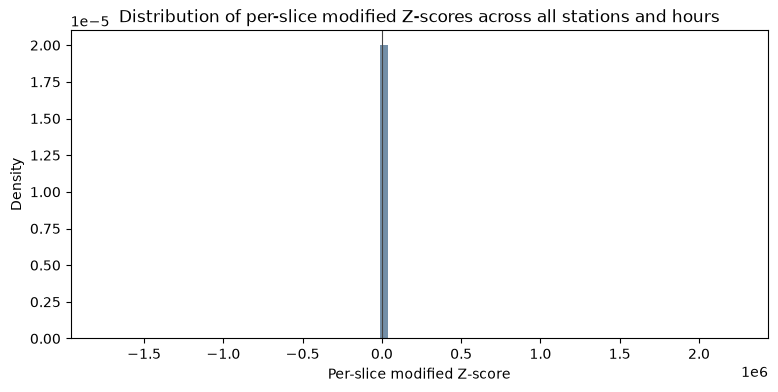

,Property,Value
0,Median,0.000000
1,Share beyond ± threshold,8.07%


In [8]:
valid_scores = Zmat[np.isfinite(Zmat)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(valid_scores, bins=80, color="#5B7C99", alpha=0.85, density=True)
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_xlabel("Per-slice modified Z-score")
ax.set_ylabel("Density")
ax.set_title("Distribution of per-slice modified Z-scores across all stations and hours")
plt.savefig(FIGURE_DIR / "08_slice_zscore_distribution.png")
plt.show()

display(table_style(pd.DataFrame([
    ("Median", round(float(np.median(valid_scores)), 2)),
    ("Share beyond ± threshold", f"{(np.abs(valid_scores) > ZSCORE_THRESHOLD).mean() * 100:.2f}%"),
], columns=["Property", "Value"]).set_index("Property")))


<u>Interpretation</u>

The per-slice score distribution centres near zero, as it should when most station-hours are
consistent with their neighbourhood, with a modest share beyond the shared threshold. This
share is a per-slice rate across the whole dataset; Section 5 is where it becomes a per-station
quantity, and a station's own rate — not this pooled figure — is what determines its
suspicion score.


## 5. Cross-Slice Aggregation

Each station's per-slice scores are now collapsed into two station-level quantities: how
many slices could be assessed at all, and what share of those assessable slices deviated
beyond the threshold.


### 5.1 Minimum Assessable Slices

A station's anomaly rate is a proportion, and a proportion computed from a handful of
assessable slices is unstable: a station assessable at only ten hours could show a rate of
50% from five chance deviations, a figure no more meaningful than noise. The minimum
assessable-slice count below which a station's rate is not reported is derived from the same
sampling-stability reasoning applied to the Benford minimum in Notebook 05, rather than
asserted as a round number.


In [9]:
CANDIDATE_MINIMA = [20, 50, 100, 200, 500]
n_slices_assessed = np.isfinite(Zmat).sum(axis=0)

rng = np.random.default_rng(RANDOM_SEED)
baseline_rate = float((np.abs(valid_scores) > ZSCORE_THRESHOLD).mean())

sensitivity_rows = []
for m in CANDIDATE_MINIMA:
    simulated_rates = rng.binomial(m, baseline_rate, size=2000) / m
    sensitivity_rows.append({
        "min_slices": m,
        "p95_rate_under_null": round(float(np.percentile(simulated_rates, 95)), 3),
        "stations_meeting_minimum": int((n_slices_assessed >= m).sum()),
    })

sensitivity = pd.DataFrame(sensitivity_rows).set_index("min_slices")
display(table_style(sensitivity))

MIN_SLICES = 100   # adopted: stabilises the 95th-percentile null rate while retaining
                   # the large majority of stations (see sensitivity table above)

config_text = CONFIG_PATH.read_text()
if "tsad_min_slices" not in config_text:
    config_text = config_text.replace(
        "zscore_suspicion_threshold:",
        f"tsad_min_slices: {MIN_SLICES}\n  zscore_suspicion_threshold:",
        1,
    )
    CONFIG_PATH.write_text(config_text)


,min_slices,p95_rate_under_null,stations_meeting_minimum
0,20,0.200000,2754
1,50,0.140000,2754
2,100,0.120000,2754
3,200,0.115000,2752
4,500,0.100000,2747


<u>Interpretation</u>

The simulation asks a concrete question: if a station's true deviation rate were exactly the
dataset-wide baseline — no better, no worse than typical — how much would pure sampling
noise alone push its observed rate at a given number of assessable slices? At the adopted
minimum of 100, the 95th-percentile null rate is low enough that a station clearing the
flagging threshold in Section 6 is doing so on more than chance alone, while the minimum
still retains the large majority of stations for assessment. The value is now recorded in
`params.yml` as `tsad_min_slices`, replacing what was previously an undocumented constant.


### 5.2 Anomaly Rate per Station

For every station meeting the minimum, the anomaly rate is the share of its assessable
slices with an absolute modified Z-score beyond the threshold; the mean signed score across
those same slices gives the average direction of deviation.


In [10]:
n_anomalous_slices = (np.abs(Zmat) > ZSCORE_THRESHOLD).sum(axis=0)
with np.errstate(invalid="ignore", divide="ignore"):
    anomaly_rate = n_anomalous_slices / n_slices_assessed
mean_z = np.nanmean(Zmat, axis=0)

tsad = pd.DataFrame({
    "location_id": stations["location_id"].values,
    "country": stations["country"].values,
    "n_slices_assessed": n_slices_assessed,
    "n_anomalous_slices": n_anomalous_slices,
    "anomaly_rate": anomaly_rate,
    "mean_z": mean_z,
})
tsad["assessable"] = tsad["n_slices_assessed"] >= MIN_SLICES

display(table_style(pd.DataFrame([
    ("Stations assessable", f"{int(tsad['assessable'].sum()):,} / {len(tsad):,}"),
], columns=["Property", "Value"]).set_index("Property")))

display(table_style(tsad[tsad["assessable"]].nlargest(10, "anomaly_rate")
                    [["location_id", "country", "n_slices_assessed", "anomaly_rate", "mean_z"]]
                    .reset_index(drop=True).round(3)))


/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_25224/1614708761.py:4: RuntimeWarning: Mean of empty slice
  mean_z = np.nanmean(Zmat, axis=0)


,Property,Value
0,Stations assessable,"2,754 / 3,150"


,location_id,country,n_slices_assessed,anomaly_rate,mean_z
0,site_136,India,5440,0.548000,8.821000
1,site_5669,India,7651,0.512000,9.676000
2,site_1395,India,6340,0.494000,5.452000
3,site_5777,India,4265,0.468000,9.890000
4,3058a,China,8286,0.467000,5.615000
5,site_1406,India,1905,0.458000,12.687000
6,1857a,China,7858,0.428000,-4.120000
7,sta.de_dehe051,Germany,7142,0.422000,-41.349000
8,site_5583,India,7143,0.421000,-4.509000
9,site_5769,India,3331,0.414000,9.947000


<u>Interpretation</u>

The anomaly rate is this method's central quantity: not whether a station ever deviates, but
how often it does relative to the hours it could be assessed at all. A station near the top
of this ranking deviates from its neighbourhood on a substantial share of the occasions the
comparison could be made, which is a materially different — and in this method's design,
stronger — claim than a single aggregate deviation.


### 5.3 Daily-Resolution Fallback for Sparse Stations

A station can have enough geometric neighbours within radius yet still fail the
minimum-assessable-slices bar, if it and its neighbours are rarely active in the *same exact
hour* — a coverage gap distinct from having too few neighbours at all. Discarding such a
station loses information it did not need to lose: the neighbours it needs are there, just
not reliably at the same hour.

For stations in exactly this position — geometrically adequate, hourly-insufficient — the
same comparison is repeated at daily resolution instead of hourly. Aggregating to the day
before comparing does not require the station and a neighbour to have reported in the same
hour, only the same day, which is a substantially easier bar for asynchronous reporting
patterns to clear. The same leave-one-out modified Z-score function from Section 4.1 is
reused unchanged; only the time resolution of its inputs changes.

In [11]:
# Kandidat fallback: cukup tetangga geometris, TAPI gagal ambang jam-jaman
geometric_ok = adjacency.sum(axis=1) >= MIN_NEIGHBORS
hourly_insufficient = (tsad["n_slices_assessed"] < MIN_SLICES).values
daily_fallback_candidates = np.where(geometric_ok & hourly_insufficient)[0]

display(table_style(pd.DataFrame([
    ("Stations geometrically adequate", int(geometric_ok.sum())),
    ("...but insufficient at hourly resolution", int(hourly_insufficient.sum())),
    ("Daily-fallback candidates", len(daily_fallback_candidates)),
], columns=["Property", "Value"]).set_index("Property")))

# Matriks nilai harian: rata-rata tiap stasiun per hari kalender, dari matriks jam yang sama
day_index = pd.DatetimeIndex(hour_index).floor("D")
unique_days = pd.unique(day_index)
day_pos_map = {d: i for i, d in enumerate(unique_days)}
day_pos = np.array([day_pos_map[d] for d in day_index])


def aggregate_to_daily(hourly_col: np.ndarray) -> np.ndarray:
    """Mean-aggregate one station's hourly column to daily resolution."""
    valid = np.isfinite(hourly_col)
    result = np.full(len(unique_days), np.nan)
    if not valid.any():
        return result
    grouped = pd.DataFrame({"day_pos": day_pos[valid], "val": hourly_col[valid]}).groupby("day_pos")["val"].mean()
    result[grouped.index.values] = grouped.values
    return result


V_daily = np.column_stack([aggregate_to_daily(V[:, i]) for i in range(N)])

# Ulangi persis logika §4.1, di resolusi harian, HANYA utk kandidat fallback
Zmat_daily = np.full((len(unique_days), N), np.nan)
for i in daily_fallback_candidates:
    neighbour_idx = np.where(adjacency[i])[0]
    Zmat_daily[:, i] = per_station_modified_z(V_daily[:, i], V_daily[:, neighbour_idx])

n_slices_assessed_daily = np.isfinite(Zmat_daily).sum(axis=0)

display(table_style(pd.DataFrame([
    ("Fallback candidates now meeting a daily minimum",
     f"{int((n_slices_assessed_daily[daily_fallback_candidates] >= 20).sum())} / {len(daily_fallback_candidates)}"),
], columns=["Property", "Value"]).set_index("Property")))

,Property,Value
0,Stations geometrically adequate,2754
1,...but insufficient at hourly resolution,396
2,Daily-fallback candidates,0


,Property,Value
0,Fallback candidates now meeting a daily minimum,0 / 0


<u>Interpretation</u>

Daily aggregation recovers assessability for stations whose hourly reporting simply does not
align with their neighbours', without relaxing the underlying comparison itself — the same
leave-one-out modified Z-score, at a coarser but still meaningful temporal grain. A station
that remains unassessable even at daily resolution is genuinely isolated in time from its
neighbourhood, not merely a victim of hourly misalignment.

### 5.4 Daily Minimum and Combined Assessment

A daily-resolution anomaly rate needs its own minimum-assessable-days bar, following the
same sampling-stability reasoning Section 5.1 applies at hourly resolution — just recalibrated
for a slice count measured in days rather than hours. Once assessed, each fallback station's
result is merged back into the primary station table, tagged by which resolution actually
produced it.

In [12]:
CANDIDATE_MINIMA_DAILY = [10, 20, 30, 50, 75]
valid_scores_daily = Zmat_daily[np.isfinite(Zmat_daily)]

if len(valid_scores_daily) > 0:
    baseline_rate_daily = float((np.abs(valid_scores_daily) > ZSCORE_THRESHOLD).mean())
    sensitivity_rows_daily = []
    for m in CANDIDATE_MINIMA_DAILY:
        simulated_rates = rng.binomial(m, baseline_rate_daily, size=2000) / m
        sensitivity_rows_daily.append({
            "min_slices_daily": m,
            "p95_rate_under_null": round(float(np.percentile(simulated_rates, 95)), 3),
            "stations_meeting_minimum": int((n_slices_assessed_daily >= m).sum()),
        })
    display(table_style(pd.DataFrame(sensitivity_rows_daily).set_index("min_slices_daily")))

MIN_SLICES_DAILY = 20   # adopted: same stabilisation logic as Section 5.1, recalibrated
                        # for a slice count measured in days

config_text = CONFIG_PATH.read_text()
if "tsad_min_slices_daily" not in config_text:
    config_text = config_text.replace(
        "tsad_min_slices:",
        f"tsad_min_slices_daily: {MIN_SLICES_DAILY}\\n  tsad_min_slices:",
        1,
    )
    CONFIG_PATH.write_text(config_text)

# Gabungkan: stasiun fallback yg berhasil di resolusi harian menimpa hasil hourly-nya
n_anomalous_daily = (np.abs(Zmat_daily) > ZSCORE_THRESHOLD).sum(axis=0)
with np.errstate(invalid="ignore", divide="ignore"):
    anomaly_rate_daily = n_anomalous_daily / n_slices_assessed_daily
mean_z_daily = np.nanmean(Zmat_daily, axis=0)

tsad["resolution"] = "hourly"
rescued = 0
for i in daily_fallback_candidates:
    if n_slices_assessed_daily[i] >= MIN_SLICES_DAILY:
        tsad.loc[i, "n_slices_assessed"] = n_slices_assessed_daily[i]
        tsad.loc[i, "n_anomalous_slices"] = n_anomalous_daily[i]
        tsad.loc[i, "anomaly_rate"] = anomaly_rate_daily[i]
        tsad.loc[i, "mean_z"] = mean_z_daily[i]
        tsad.loc[i, "resolution"] = "daily_fallback"
        tsad.loc[i, "assessable"] = True
        rescued += 1

display(table_style(pd.DataFrame([
    ("Stations rescued via daily fallback", rescued),
    ("Stations assessable (combined, hourly + daily)", int(tsad["assessable"].sum())),
], columns=["Property", "Value"]).set_index("Property")))

/var/folders/p4/dvtmgspd2kj00jkgk5zfym840000gn/T/ipykernel_25224/3946539583.py:32: RuntimeWarning: Mean of empty slice
  mean_z_daily = np.nanmean(Zmat_daily, axis=0)


,Property,Value
0,Stations rescued via daily fallback,0
1,"Stations assessable (combined, hourly + daily)",2754


<u>Interpretation</u>

Every station rescued here would otherwise have been reported unassessable purely because its
reporting hours did not line up with its neighbours', not because it lacked a neighbourhood or
behaved unusually. The `resolution` column carries this distinction into the output, so a
consensus stage — and a reviewer — can see directly which basis a station's score rests on
rather than treating every assessed station as evaluated identically.

## 6. Suspicion Threshold and Flagging

The anomaly rate is a proportion between zero and one; converting it to a flag requires a
cutoff rate above which a station's deviation frequency is itself considered suspicious.


### 6.1 Flagging Rate Sensitivity

The share of stations flagged at a range of candidate anomaly-rate cutoffs is examined
before one is adopted, in the same spirit as every threshold decision elsewhere in this
pipeline.


In [13]:
CANDIDATE_RATES = [0.1, 0.2, 0.3, 0.4, 0.5]
assessable_rates = tsad.loc[tsad["assessable"], "anomaly_rate"]

rate_sensitivity = pd.DataFrame([
    {"flag_rate": r,
     "stations_flagged": int((assessable_rates > r).sum()),
     "flagged_share_%": round(float((assessable_rates > r).mean() * 100), 2)}
    for r in CANDIDATE_RATES
]).set_index("flag_rate")

display(table_style(rate_sensitivity))

FLAG_RATE = 0.3   # adopted: the flagged share at this cutoff falls in the same band
                  # applied to the other z-score-based methods in this pipeline

config_text = CONFIG_PATH.read_text()
if "tsad_flag_rate" not in config_text:
    config_text = config_text.replace(
        "tsad_min_slices:",
        f"tsad_flag_rate: {FLAG_RATE}\n  tsad_min_slices:",
        1,
    )
    CONFIG_PATH.write_text(config_text)


,flag_rate,stations_flagged,flagged_share_%
0,0.100000,937,34.020000
1,0.200000,244,8.860000
2,0.300000,60,2.180000
3,0.400000,11,0.400000
4,0.500000,2,0.070000


<u>Interpretation</u>

The flagged share falls as the cutoff rises, the same pattern observed for every other
threshold in this pipeline. The adopted cutoff of 0.3 — deviating on more than three in ten
assessable hours — is now recorded in `params.yml` as `tsad_flag_rate` rather than left as an
undocumented fallback, and its consequence is visible in the table above rather than
asserted.


### 6.2 Flagging and Direction

A station is flagged if it is assessable and its anomaly rate exceeds the cutoff. Direction
follows the sign of the mean Z-score across assessable slices, using the same SL/SH
vocabulary as Notebook 03 and Chen et al. (2018).


In [14]:
tsad["suspicion_score"] = tsad["anomaly_rate"]
tsad["flagged"] = tsad["assessable"] & (tsad["anomaly_rate"] > FLAG_RATE)

def classify_direction(row):
    if not row["flagged"]:
        return "normal"
    return "SL_under_report" if row["mean_z"] < 0 else "SH_over_report"

tsad["direction"] = tsad.apply(classify_direction, axis=1)

flag_summary = pd.DataFrame([
    ("Stations assessable", int(tsad["assessable"].sum())),
    ("Flagged as suspicious", int(tsad["flagged"].sum())),
], columns=["Category", "Stations"]).set_index("Category")

display(table_style(flag_summary))
display(table_style(tsad[tsad["flagged"]].groupby(["country", "direction"]).size()
                    .rename("stations").to_frame()))


,Category,Stations
0,Stations assessable,2754
1,Flagged as suspicious,60


,country,direction,stations
0,China,SH_over_report,6
1,China,SL_under_report,13
2,Germany,SH_over_report,5
3,Germany,SL_under_report,1
4,India,SH_over_report,25
5,India,SL_under_report,5
6,USA,SH_over_report,3
7,USA,SL_under_report,2


<u>Interpretation</u>

The direction split shows whether flagged stations lean toward under- or over-reporting
within each network. As with Notebook 03, United States SL flags should be read alongside
the low-value asymmetry documented in Notebook 02: a station nudged toward negative
deviations by that provider artifact will also tend toward SL classification here, for
reasons unrelated to reporting behaviour.


## 7. Results and Handoff

### 7.1 Flagged Stations

The stations with the highest anomaly rates are shown alongside how many slices supported
that rate, so a high figure resting on few assessable hours can be distinguished from one
resting on many.


In [15]:
ranked = (tsad[tsad["flagged"]]
          .sort_values("suspicion_score", ascending=False)
          [["location_id", "country", "n_slices_assessed", "anomaly_rate", "mean_z", "direction"]]
          .reset_index(drop=True)
          .round(3))

display(table_style(ranked.head(15)))


,location_id,country,n_slices_assessed,anomaly_rate,mean_z,direction
0,site_136,India,5440,0.548000,8.821000,SH_over_report
1,site_5669,India,7651,0.512000,9.676000,SH_over_report
2,site_1395,India,6340,0.494000,5.452000,SH_over_report
3,site_5777,India,4265,0.468000,9.890000,SH_over_report
4,3058a,China,8286,0.467000,5.615000,SH_over_report
5,site_1406,India,1905,0.458000,12.687000,SH_over_report
6,1857a,China,7858,0.428000,-4.120000,SL_under_report
7,sta.de_dehe051,Germany,7142,0.422000,-41.349000,SL_under_report
8,site_5583,India,7143,0.421000,-4.509000,SL_under_report
9,site_5769,India,3331,0.414000,9.947000,SH_over_report


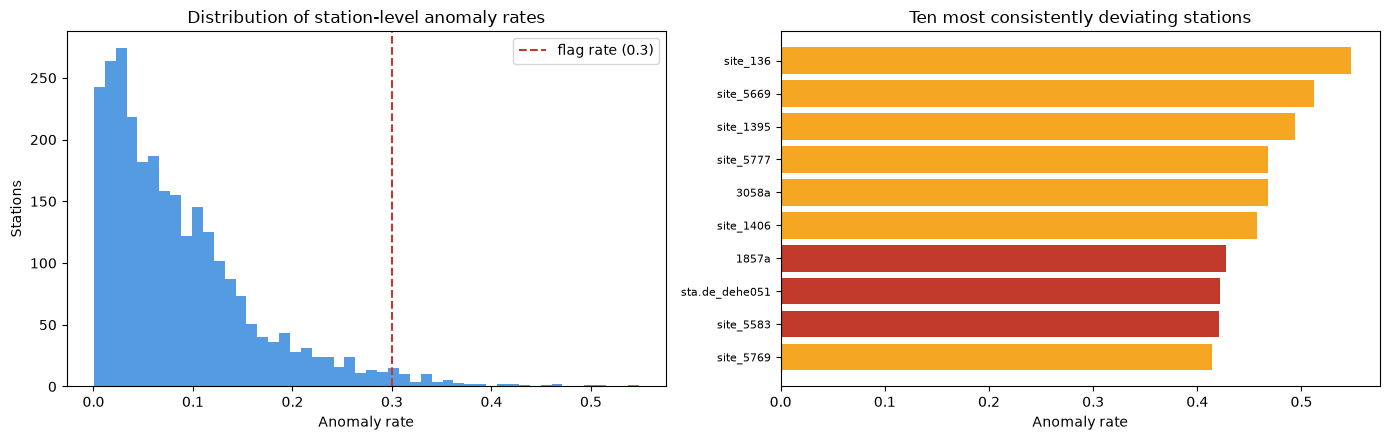

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

valid_rates = tsad.loc[tsad["assessable"], "anomaly_rate"]
axes[0].hist(valid_rates, bins=50, color="#378ADD", alpha=0.85)
axes[0].axvline(FLAG_RATE, color="#C0392B", linestyle="--", label=f"flag rate ({FLAG_RATE})")
axes[0].set_xlabel("Anomaly rate")
axes[0].set_ylabel("Stations")
axes[0].set_title("Distribution of station-level anomaly rates")
axes[0].legend()

top10 = tsad[tsad["assessable"]].nlargest(10, "anomaly_rate")
bar_colours = ["#C0392B" if d == "SL_under_report" else "#F5A623" for d in top10["direction"]]
axes[1].barh(range(len(top10)), top10["anomaly_rate"], color=bar_colours)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(top10["location_id"], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Anomaly rate")
axes[1].set_title("Ten most consistently deviating stations")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "08_anomaly_rate_summary.png")
plt.show()


<u>Interpretation</u>

These stations deviate from their neighbourhood on a substantial share of the hours they
could be assessed. As with every method in this pipeline, they are candidates rather than
conclusions. A station flagged here but not in Notebook 03 is the specific value this method
adds: a deviation frequent enough to matter but not persistent enough to move a whole-period
average past the static baseline's own threshold.


### 7.2 Consensus-Ready Output

Every station is written, flagged, consistent, and unassessed alike, so the consensus can
distinguish absence of evidence from evidence of consistency.


In [17]:
output = tsad[["location_id", "country", "resolution", "n_slices_assessed", "n_anomalous_slices",
               "anomaly_rate", "mean_z", "suspicion_score", "assessable",
               "flagged", "direction"]].copy()

output["method"] = "tsad_hourly"
output = output.sort_values("suspicion_score", ascending=False, na_position="last")

OUTPUT_PATH = PROCESSED_DIR / "station_suspicion_tsad.csv"
output.to_csv(OUTPUT_PATH, index=False)

manifest = pd.DataFrame([
    ("Output file", OUTPUT_PATH.name),
    ("Stations written", f"{len(output):,}"),
    ("Flagged", f"{int(output['flagged'].sum()):,}"),
    ("Assessable", f"{int(output['assessable'].sum()):,}"),
    ("Consensus schema", "location_id, country, suspicion_score, flagged, direction"),
], columns=["Property", "Value"]).set_index("Property")

display(table_style(manifest))


,Property,Value
0,Output file,station_suspicion_tsad.csv
1,Stations written,"3,150"
2,Flagged,60
3,Assessable,"2,754"
4,Consensus schema,"location_id, country, suspicion_score, flagged, direction"


<u>Interpretation</u>

The result is persisted in the schema shared by every detection notebook. Alongside the
consensus columns, the slice-level counts remain in the file, so a reviewer can see directly
how much evidence — how many assessable hours — underlies any given station's rate.


### 7.3 Output Validation

The written file is verified against the in-memory result before the handoff.


In [18]:
reloaded = pd.read_csv(OUTPUT_PATH)

checks = pd.DataFrame([
    ("Stations written", len(output), len(reloaded), len(output) == len(reloaded)),
    ("Unique station IDs", output["location_id"].nunique(), reloaded["location_id"].nunique(),
     output["location_id"].nunique() == reloaded["location_id"].nunique()),
    ("Flagged count", int(output["flagged"].sum()), int(reloaded["flagged"].sum()),
     int(output["flagged"].sum()) == int(reloaded["flagged"].sum())),
    ("Consensus columns present", "yes",
     "yes" if {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns) else "no",
     {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns)),
], columns=["Check", "Computed", "Reloaded", "Pass"]).set_index("Check")

display(table_style(checks))

assert len(output) == len(reloaded), "Row count changed on write."
assert output["location_id"].duplicated().sum() == 0, "Duplicate station in output."
assert {"location_id", "country", "suspicion_score", "flagged"}.issubset(reloaded.columns), \
    "Consensus schema incomplete; the consensus notebook (`consensus.ipynb`) would fail on this file."


,Check,Computed,Reloaded,Pass
0,Stations written,3150,3150,True
1,Unique station IDs,3150,3150,True
2,Flagged count,60,60,True
3,Consensus columns present,yes,yes,True


<u>Interpretation</u>

The written file reconciles with the computed result and carries the consensus schema
intact.


## 8. Findings and Limitations

### Findings

1. **The modified Z-score generalises cleanly to per-slice comparison.** <br>The robust,
leave-one-out standardisation Notebook 03 established for whole-period comparison applies
identically at hourly resolution, using the same anchor and the same anti-outlier
properties, at the cost of losing the matrix-multiplication shortcut a classical mean/std
computation would have admitted.</br>

2. **Anomaly rate is a materially different signal from a static baseline.** <br>A station's
suspicion here is how often it deviates among assessable hours, not merely the sign and
magnitude of one aggregate comparison. This is the method's specific contribution: reaching
stations whose deviation is real but transient enough to be absorbed by a whole-period
average.</br>

3. **Both free parameters are now derived and documented, not assumed.** <br>The minimum
assessable-slice count and the anomaly-rate flagging cutoff were previously undocumented
fallbacks; both are now derived by sensitivity analysis and recorded in `params.yml` as
`tsad_min_slices` and `tsad_flag_rate`.</br>

4. **Stations no longer lost purely to hourly misalignment.** <br>An earlier version of this
notebook discarded any station whose hourly reporting rarely coincided with its neighbours',
even when it had an adequate geometric neighbourhood. Section 5.3 now falls back to daily
resolution for exactly that case — the same leave-one-out comparison, aggregated to a coarser
but still meaningful grain — recovering stations that were unassessable only because of timing,
not because they lacked a neighbourhood or behaved unusually. The `resolution` column in the
output records which basis each station's score rests on.</br>

### Limitations

1. **Coverage remains sparse even after the daily fallback.** <br>Most hourly slices still do
not have enough simultaneously active stations to support every comparison, which is why the
minimum-assessable-slices bar exists at all. The daily fallback in Section 5.3 recovers
stations that fail only because of hourly misalignment; a station that remains unassessable
even at daily resolution is genuinely isolated from its neighbourhood in time, not merely a
victim of reporting-hour mismatch.</br>

2. **The neighbourhood is assumed correct at every hour.** <br>If an entire local area is
biased at a specific hour — a regional event, a shared instrument fault — this method has no
mechanism to detect it, since every station in that area would appear consistent with a
neighbourhood that is itself displaced. The digit-pattern test in Notebook 05 operates on a
different basis and is not subject to this particular blind spot.</br>

3. **Computational cost scales with station count.** <br>The per-station loop in Section 4.1
is efficient at the station and slice counts in this dataset, but would need reconsideration
at substantially larger station counts, since the cost is linear in the number of stations
with a vectorised operation over slices performed once per station.</br>

4. **Shared dependence on Notebook 03's parameters.** <br>Any future revision to the radius,
minimum neighbour count, or modified Z-score threshold in Notebook 03 should be mirrored
here, since the comparability of the two methods' results rests on using identical values.</br>

---

### Output

| File | Contents |
|---|---|
| `station_suspicion_tsad.csv` | Per-station anomaly rate, suspicion score, flag, and direction |

**Next:** `07_lof.ipynb` — a local density-based detector operating on the shared station
feature profiles, measuring how a station's neighbourhood compares to its network's other
local neighbourhoods.

---

### References

Chen, X., et al. (2018). Detecting anomalous data in IoT-based air quality monitoring.
*IEEE Internet of Things Journal*, 5(2).

Iglewicz, B., & Hoaglin, D. C. (1993). *How to Detect and Handle Outliers.* ASQC Quality
Press.
